In [1]:
# Offline auto-encoder algorithm. Codes are derived and edited from https://www.geeksforgeeks.org/anomaly-detection-in-time-series-data/
import pandas as pd
import tensorflow as tf
from keras.layers import Input, Dense
from keras.models import Model
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

data = pd.read_csv(
	'bmereading_1.csv')
data = data[['eCO2', 'TVOC']]


,908b,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,eCO2,TVOC,Unnamed: 7,Unnamed: 8
0,1,1,0,1,21,400,0,255,0
1,1,2,0,1,22,400,0,255,0
2,1,3,0,1,23,400,0,255,0
3,1,4,0,1,24,400,0,255,0
4,1,5,0,1,25,400,0,255,0
...,...,...,...,...,...,...,...,...,...
9322,1,9323,2,48,21,466,113,255,0
9323,1,9324,2,48,22,477,115,255,0
9324,1,9325,2,48,23,471,118,255,0
9325,1,9326,2,48,24,473,118,255,0


In [ ]:
train_df = pd.read_csv('background.csv')
train_df = train_df[['eCO2', 'TVOC']]
train_df = train_df.head(40000)

In [9]:

data_tensor = tf.convert_to_tensor(data.values, dtype=tf.float32)
data_tensor = tf.convert_to_tensor(data.values, dtype=tf.float32)

# Define the autoencoder model
input_dim = data.shape[1]
print(input_dim)
encoding_dim = 10

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation='relu')(input_layer)
decoder = Dense(input_dim, activation='relu')(encoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Compile and fit the model
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(data_tensor, data_tensor, epochs=50,
				batch_size=32, shuffle=True)

9
Epoch 1/50
 25/292 [=>............................] - ETA: 1s - loss: 6074900.5000

2023-09-20 20:01:23.269196: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


292/292 [==============================] - 1s 4ms/step - loss: 2703711.2500
Epoch 2/50
292/292 [==============================] - 1s 4ms/step - loss: 597316.0000
Epoch 3/50
292/292 [==============================] - 1s 4ms/step - loss: 483707.0000
Epoch 4/50
292/292 [==============================] - 1s 4ms/step - loss: 573940.1250
Epoch 5/50
292/292 [==============================] - 1s 4ms/step - loss: 629477.6250
Epoch 6/50
292/292 [==============================] - 1s 4ms/step - loss: 639890.3125
Epoch 7/50
292/292 [==============================] - 1s 4ms/step - loss: 637504.3750
Epoch 8/50
292/292 [==============================] - 1s 4ms/step - loss: 627032.5625
Epoch 9/50
292/292 [==============================] - 1s 4ms/step - loss: 614619.1875
Epoch 10/50
292/292 [==============================] - 1s 4ms/step - loss: 602710.7500
Epoch 11/50
292/292 [==============================] - 1s 4ms/step - loss: 590225.4375
Epoch 12/50
292/292 [==============================] - 1s 4ms/

2023-09-20 20:02:17.135761: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


292/292 [==============================] - 0s 1ms/step
Precision:  1.0
Recall:  1.0
F1 Score:  1.0


In [ ]:
# Calculate the reconstruction error for each data point
reconstructions = autoencoder.predict(data_tensor)
mse = tf.reduce_mean(tf.square(data_tensor - reconstructions),
					axis=1)
anomaly_scores = pd.Series(mse.numpy(), name='anomaly_scores')
anomaly_scores.index = data.index


In [16]:

threshold = anomaly_scores.quantile(0.9)
anomalous = anomaly_scores > threshold
binary_labels = anomalous.astype(int)
precision, recall,\
	f1_score, _ = precision_recall_fscore_support(
		binary_labels, anomalous, average='binary')

predictions = anomaly_scores.values

print("Precision: ", precision)
print("Recall: ", recall)
print("F1 Score: ", f1_score)

Precision:  1.0
Recall:  1.0
F1 Score:  1.0


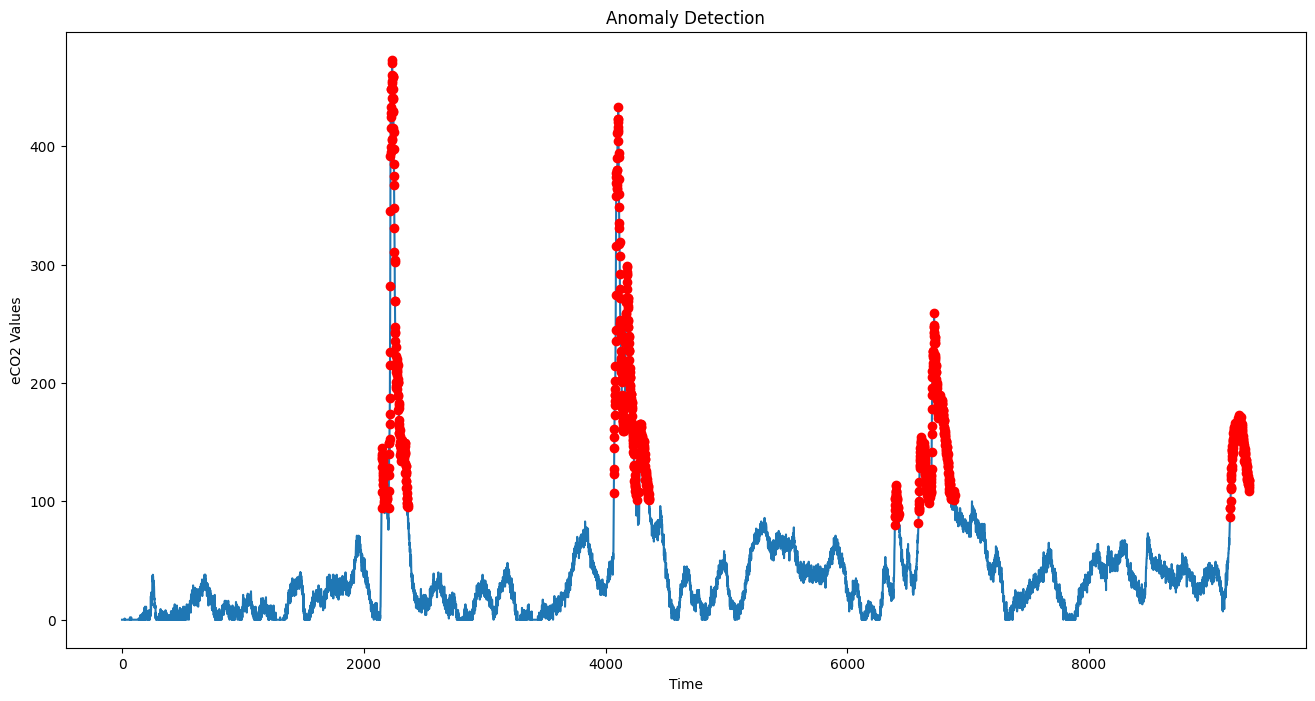

In [17]:
# Plot the data with anomalies marked in red
plt.figure(figsize=(16, 8))
column = data['TVOC']
plt.plot(column.index,
		column)
plt.plot(column.index[anomalous],
		column[anomalous], 'ro')
plt.title('Anomaly Detection')
plt.xlabel('Time')
plt.ylabel('eCO2 Values')
plt.show()
